# Bootstrap Sampling: SPY (S&P 500 Index)
This study is broken down into two parts. The first section explores bootstrap resampling relating to monthly S&P 500 index returns. The objective is to generate a confidence interval for monthly returns and variation, and see how they change throughout time. The second section investigates whether the bootstrap can be converted into position sizing rules that outperforms the index on a risk-adjusted basis.

The bootstrap sampling method is a powerful statistical tool used to estimate the sampling distribution for a statistic $T$. The SPY index is used as a proxy for the S&P 500 index. The index was initially launched in 1957, whereas the SPY ETF was created in 1993. We can think of the SPY as a *relatively* recent sample for the entire history of the S&P 500 index.

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
import warnings

# Settings
plt.style.use("ggplot")
warnings.filterwarnings("ignore")

In [60]:
# Download monthly close data
data = yf.download("SPY", period="max", interval="1mo", auto_adjust=True)["Close"]

# Sample date range
print(data.index[0])
print(data.index[-1])

# 95% Confidence Interval
intervals = [2.5, 97.5]

data.describe()

[*********************100%***********************]  1 of 1 completed

1993-01-01 00:00:00
2026-04-01 00:00:00


Ticker,SPY
count,400.000000
mean,169.878046
std,157.714370
min,24.175379
25%,70.306774
50%,96.127029
75%,231.728371
max,690.085327


In [61]:
# Comptute returns
returns = (data / data.shift(1)) - 1
returns = returns["SPY"].dropna()

print(f"Sample mean: {returns.mean():.4f}")
print(f"Sample sdev: {returns.std():.4f}")
print(f"Sample skew: {returns.skew():.4f}")
print(f"Sample kurt: {returns.kurtosis():.4f}")

Sample mean: 0.0094
Sample sdev: 0.0431
Sample skew: -0.5363
Sample kurt: 0.9483


From the return sample 01/01/1993 to 04/01/2026, the SPY had an average monthly return of 0.94% and a monthly standard deviation of 4.31%. The sample has a negative skew indicating a fat left tail. The graphs below visualize this information.

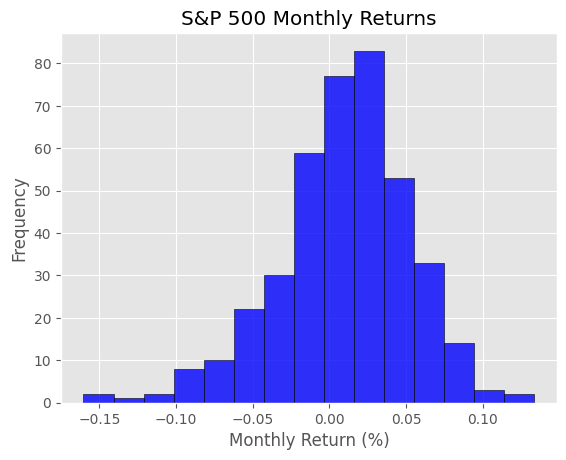

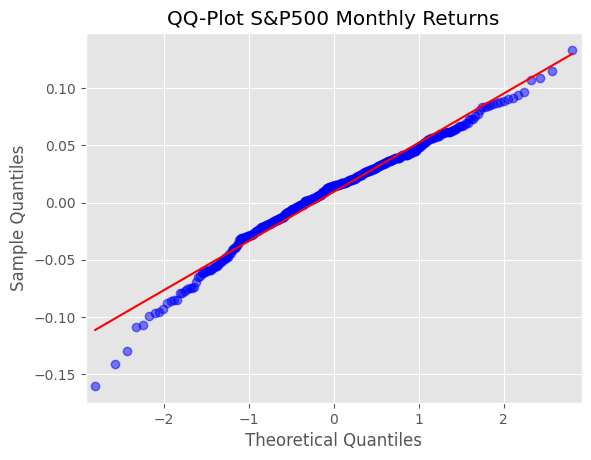

In [62]:
# Plot the histogram of monthly returns
plt.hist(returns, bins=15, color="blue", alpha=0.8, edgecolor="black")
plt.xlabel("Monthly Return (%)")
plt.ylabel("Frequency")
plt.title("S&P 500 Monthly Returns")
plt.show()

# Plot the Q-Q of monthly returns
sm.qqplot(returns, line="s", markerfacecolor='b', markeredgecolor='b', alpha=0.5)
plt.title("QQ-Plot S&P500 Monthly Returns")
plt.show()

### Part 1: Bootstrap Resampling: Mean and Standard Deviation
Knowing the average return of a market index and the variability of its returns is an essential piece of information for investors. These statistics form the foundation of expectations and financial models.

$$
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
$$

Unlike conventional resampling, time-series data requires the maintenance of its temporal structure. To keep this structure, individual sets of returns are generated into "blocks". A block size is length $N$. A block starting at time $i$ is defined as $B_i=\{R_i,R_{i+1},...,R_{i+N-1}\}$. Thus, the set of all overlapping blocks is,

$$
\Beta = \{B_1,B_2,...,B_{T-N+1}\}
$$

These blocks are then sampled with replacement to compute the statistic $T$, we want to estimate. Because we are interested in the average (expected) return and its variability, out statistics are $\hat{E[X]}$ and $\hat{Var[X]}$, where $X$ is a continuous random variable of monthly returns, $E[X]$ is its expected value, and $Var[X]$ its variance.

In [63]:
# Create blocks (keeping temporal structure)
N = int(len(returns) / 12)
blocks = np.array_split(returns, N)

In [64]:
B = 10_000

rng = np.random.default_rng()

bootstrap_mu = []
bootstrap_sd = []
for b in range(B):
    idx = rng.integers(0, len(blocks), size=N)
    sampled_blocks = [blocks[i] for i in idx]
    sample = np.concatenate(sampled_blocks)
    
    # Save the resampled statistics
    bootstrap_mu.append(sample.mean())
    bootstrap_sd.append(sample.std())

mu_ci = np.percentile(bootstrap_mu, intervals)
sd_ci = np.percentile(bootstrap_sd, intervals)

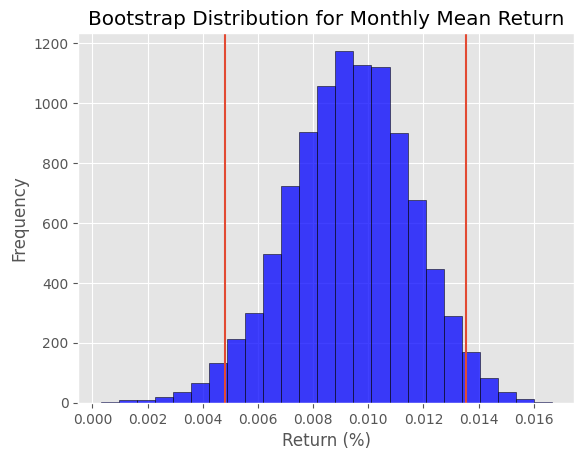

Bootstrap mean:           0.009337125330380237
Bootstrap standard error: 0.002209464380370236
2.5% Confidence Interval: 0.00479808340334082
97.5% Confidence Interval: 0.013547520351967976


In [65]:
# Plot the bootstrap distribution for mean
plt.hist(bootstrap_mu, bins=25, color="blue", alpha=0.75, edgecolor="black")
plt.axvline(mu_ci[0])
plt.axvline(mu_ci[1])
plt.title("Bootstrap Distribution for Monthly Mean Return")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.show()

# Print bootstrap statistics (simple returns)
print(f"Bootstrap mean:           {np.mean(bootstrap_mu)}")
print(f"Bootstrap standard error: {np.std(bootstrap_mu)}")
print(f"{intervals[0]}% Confidence Interval: {mu_ci[0]}")
print(f"{intervals[1]}% Confidence Interval: {mu_ci[1]}")

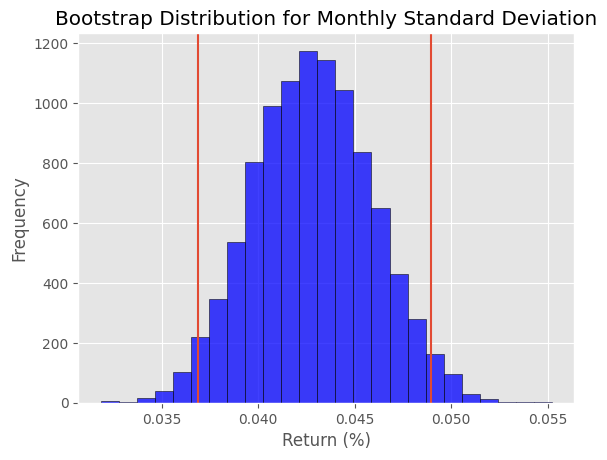

Bootstrap mean:           0.042841762858596644
Bootstrap standard error: 0.0030776812359298005
2.5% Confidence Interval: 0.03690427901320907
97.5% Confidence Interval: 0.04895826425210905


In [66]:
# Plot the bootstrap distribution for standard deviation
plt.hist(bootstrap_sd, bins=25, color="blue", alpha=0.75, edgecolor="black")
plt.axvline(sd_ci[0])
plt.axvline(sd_ci[1])
plt.title("Bootstrap Distribution for Monthly Standard Deviation")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.show()

# Print bootstrap statistics (simple returns)
print(f"Bootstrap mean:           {np.mean(bootstrap_sd)}")
print(f"Bootstrap standard error: {np.std(bootstrap_sd)}")
print(f"{intervals[0]}% Confidence Interval: {sd_ci[0]}")
print(f"{intervals[1]}% Confidence Interval: {sd_ci[1]}")

In [67]:
# Compute the bootstrap sample bias
bias_mu = np.mean(bootstrap_mu) - returns.mean()
bias_sd = np.mean(bootstrap_sd) - returns.std()

# Standardized Bias
s_bias_mu = bias_mu / np.std(bootstrap_mu)
s_bias_sd = bias_sd / np.std(bootstrap_sd)

print(f"Bias of Bootstrap Distribution for Mean: {bias_mu:.4f} | {s_bias_mu:.4f}")
print(f"Bias of Bootstrap Distribution for Stdv: {bias_sd:.4f} | {s_bias_sd:.4f}")

Bias of Bootstrap Distribution for Mean: -0.0000 | -0.0075
Bias of Bootstrap Distribution for Stdv: -0.0002 | -0.0716


As we can see from the boostrap results above, the estimation for the sampling distribution of $E[R]$ and $Var[R]$ are centered close to the observed sample statistics. From this bootstrap, we are 95% confident that the true mean monthly return is between 0.486% and 1.354% and that the true monthly standard deviation is between 3.69% and 4.91%.

Due to the statistics in question, there is no bias for the estimates of the SPY population mean and standard deviation.

Because this is time-series data, a more meaningful insight would be as to how the mean bootstrap estimate and confidence intervals change over time.

In [68]:
B = 1_000
lookback = 60

bootstrap_mu = [] # Mean of the bootstrap distribution for mu
bootstrap_sd = [] # Mean of the bootstrap distribution for sd

# Confidence intervals (95%)
ci_mu_lower = []
ci_mu_upper = []
ci_sd_lower = []
ci_sd_upper = []

for i in range(lookback, len(returns)):
    # Extract return sample
    s_returns = returns[i-lookback:i]
    
    # Create blocks (keeping temporal structure)
    N = int(len(s_returns) / 12)
    blocks = np.array_split(s_returns, N)
    
    rng = np.random.default_rng()

    t_mu = []
    t_sd = []
    for b in range(B):
        idx = rng.integers(0, len(blocks), size=N)
        sampled_blocks = [blocks[i] for i in idx]
        sample = np.concatenate(sampled_blocks)
        
        # Save the resampled statistics
        t_mu.append(sample.mean())
        t_sd.append(sample.std())
        
    # Store confidence intervals
    mu_ci = np.percentile(t_mu, intervals)
    sd_ci = np.percentile(t_sd, intervals)

    ci_mu_lower.append(mu_ci[0])
    ci_mu_upper.append(mu_ci[1])
    ci_sd_lower.append(sd_ci[0])
    ci_sd_upper.append(sd_ci[1])

    # Store mean statistics
    bootstrap_mu.append(np.mean(t_mu))
    bootstrap_sd.append(np.mean(t_sd))

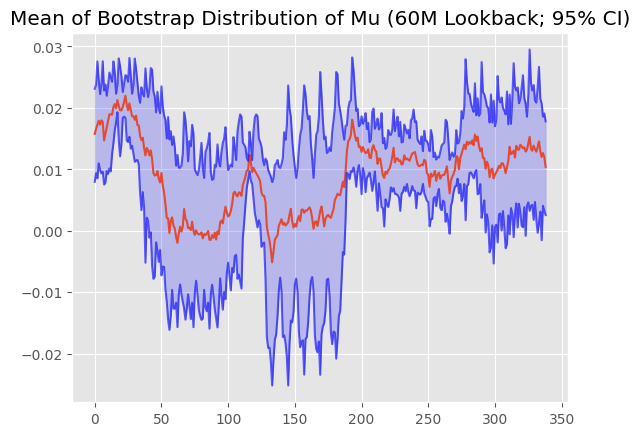

In [69]:
x = np.arange(len(bootstrap_mu))

plt.plot(x, bootstrap_mu)
plt.plot(x, ci_mu_lower, color="blue", alpha=0.60)
plt.plot(x, ci_mu_upper, color="blue", alpha=0.60)
plt.fill_between(x, ci_mu_lower, ci_mu_upper, color="blue", alpha=0.2)
plt.title("Mean of Bootstrap Distribution of Mu (60M Lookback; 95% CI)")
plt.show()

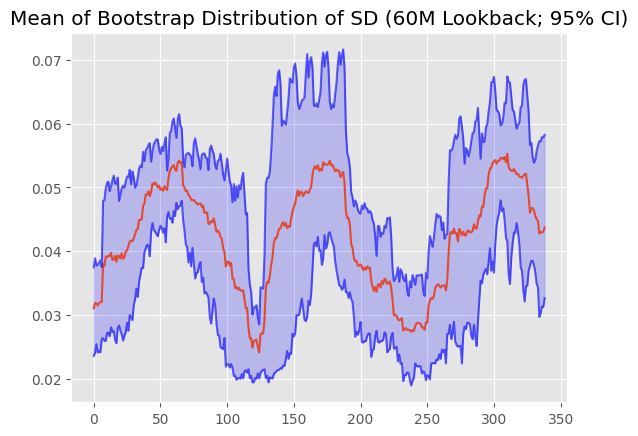

In [70]:
x = np.arange(len(bootstrap_sd))

plt.plot(x, bootstrap_sd)
plt.plot(x, ci_sd_lower, color="blue", alpha=0.60)
plt.plot(x, ci_sd_upper, color="blue", alpha=0.60)
plt.fill_between(x, ci_sd_lower, ci_sd_upper, color="blue", alpha=0.2)
plt.title("Mean of Bootstrap Distribution of SD (60M Lookback; 95% CI)")
plt.show()

There are two interesting results from these graphs. First, the mean boostrap distribution seems to be cyclical for both the mean and standard deviation. Secondly, the confidence intervals exhibit periods of narrow and wide breadths.

Below visualizes the spreads.

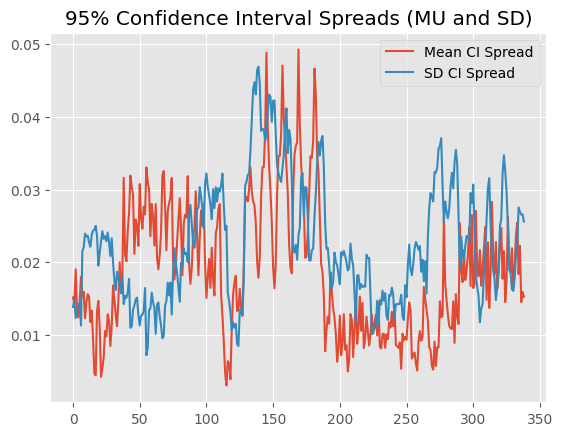

In [71]:
ci_mu_spread = np.array(ci_mu_upper) - np.array(ci_mu_lower)
ci_sd_spread = np.array(ci_sd_upper) - np.array(ci_sd_lower)

plt.plot(ci_mu_spread, label="Mean CI Spread")
plt.plot(ci_sd_spread, label="SD CI Spread")
plt.title("95% Confidence Interval Spreads (MU and SD)")
plt.legend()
plt.show()

### Part 2: Confidence-Weighted Positions

       mu_lower_bound  uncertainty      weight
count      374.000000   374.000000  374.000000
mean         0.004515     0.007288    0.594352
std          0.011192     0.003037    0.170024
min         -0.033013     0.002824    0.191043
25%          0.001241     0.004834    0.501702
50%          0.006513     0.006980    0.612863
75%          0.012906     0.008984    0.720408
max          0.021991     0.017844    0.902283
Average weight: 0.5943515823037617
Median weight: 0.6128627264255921
Min weight: 0.1910434278851545
Max weight: 0.9022825288429386
Pct months fully risk-off: 0.0
Pct months near full long (>=0.9): 0.0053475935828877


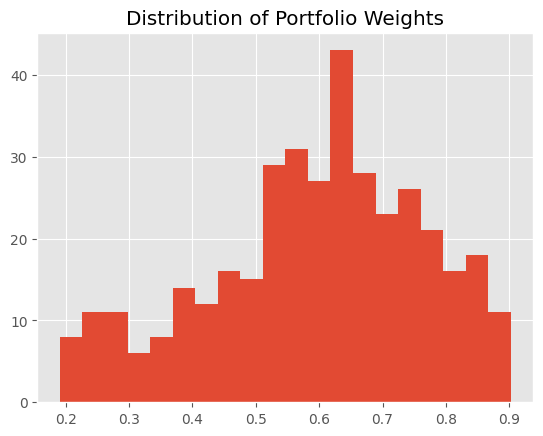

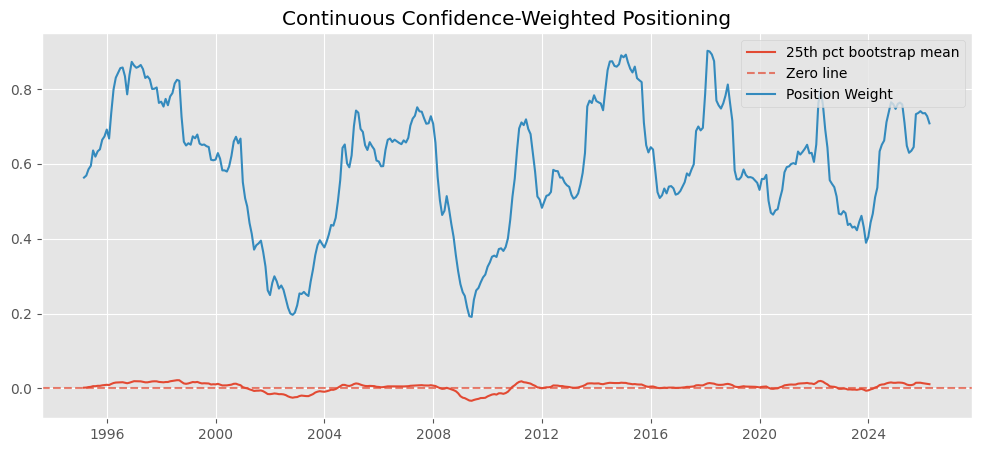

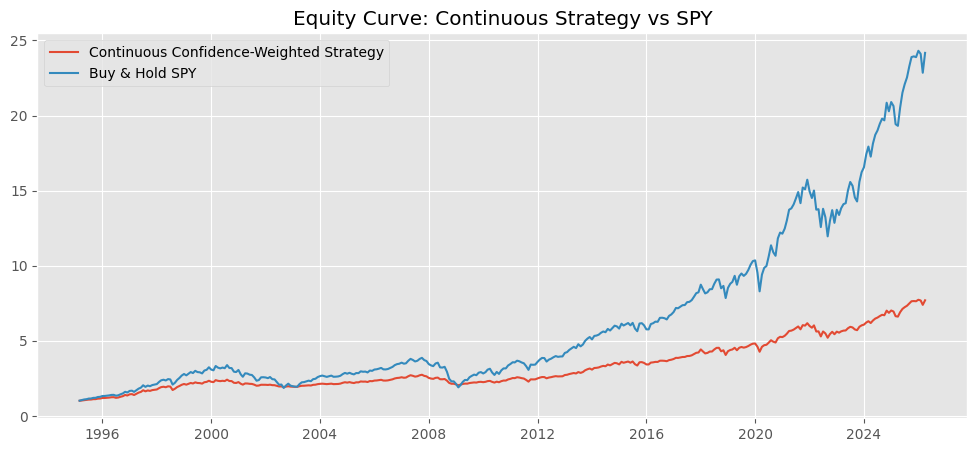

In [82]:
B = 1_000
lookback = 24
block_len = 3
rng = np.random.default_rng(123)

# Controls
lower_bound_pct = 25
uncertainty_penalty_k = 5.0
signal_scale = 2.0   # larger = less aggressive response
min_weight = -0.5
max_weight = 1.0

weight_dates = []
lower_bounds = []
mu_boot_means = []
mu_boot_stds = []
uncertainty_vals = []
weights = []
strategy_ret = []
benchmark_ret = []

for i in range(lookback, len(returns) - 1):
    s_returns = returns.iloc[i - lookback:i].to_numpy()

    # Build overlapping blocks
    if len(s_returns) < block_len:
        continue

    blocks = np.lib.stride_tricks.sliding_window_view(s_returns, block_len)
    n_available_blocks = len(blocks)

    # Number of sampled blocks needed to reconstruct a sample
    k = int(np.ceil(len(s_returns) / block_len))

    t_mu = []
    for b in range(B):
        idx = rng.integers(0, n_available_blocks, size=k)
        sampled_blocks = blocks[idx].reshape(-1)
        sample = sampled_blocks[:len(s_returns)]
        t_mu.append(sample.mean())

    t_mu = np.asarray(t_mu)

    lower_bound = np.percentile(t_mu, lower_bound_pct)
    mu_hat = np.median(t_mu)
    uncertainty = np.std(t_mu, ddof=1)

    # Continuous mapping:
    # negative lower bounds now reduce weight smoothly instead of forcing 0
    edge = lower_bound / (uncertainty + 1e-8)

    # Logistic map to (0,1), centered at 0
    base_weight = 1.0 / (1.0 + np.exp(-edge / signal_scale))

    # Uncertainty penalty
    penalty = 1.0 / (1.0 + uncertainty_penalty_k * uncertainty)

    w = base_weight * penalty
    w = np.clip(w, min_weight, max_weight)

    next_ret = returns.iloc[i + 1]

    weight_dates.append(returns.index[i + 1])
    lower_bounds.append(lower_bound)
    mu_boot_means.append(mu_hat)
    mu_boot_stds.append(np.std(t_mu, ddof=1))
    uncertainty_vals.append(uncertainty)
    weights.append(w)
    strategy_ret.append(w * next_ret)
    benchmark_ret.append(next_ret)

position_df = pd.DataFrame({
    "mu_lower_bound": lower_bounds,
    "mu_boot_mean": mu_boot_means,
    "mu_boot_std": mu_boot_stds,
    "uncertainty": uncertainty_vals,
    "weight": weights,
    "strategy_return": strategy_ret,
    "benchmark_return": benchmark_ret,
}, index=pd.to_datetime(weight_dates))

position_df["strategy_equity"] = (1 + position_df["strategy_return"]).cumprod()
position_df["benchmark_equity"] = (1 + position_df["benchmark_return"]).cumprod()

print(position_df[["mu_lower_bound", "uncertainty", "weight"]].describe())

print("Average weight:", position_df["weight"].mean())
print("Median weight:", position_df["weight"].median())
print("Min weight:", position_df["weight"].min())
print("Max weight:", position_df["weight"].max())
print("Pct months fully risk-off:", (position_df["weight"] == 0).mean())
print("Pct months near full long (>=0.9):", (position_df["weight"] >= 0.9).mean())

position_df["weight"].hist(bins=20)
plt.title("Distribution of Portfolio Weights")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(position_df.index, position_df["mu_lower_bound"], label=f"{lower_bound_pct}th pct bootstrap mean")
plt.axhline(0.0, linestyle="--", alpha=0.7, label="Zero line")
plt.plot(position_df.index, position_df["weight"], label="Position Weight")
plt.title("Continuous Confidence-Weighted Positioning")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(position_df.index, position_df["strategy_equity"], label="Continuous Confidence-Weighted Strategy")
plt.plot(position_df.index, position_df["benchmark_equity"], label="Buy & Hold SPY")
plt.title("Equity Curve: Continuous Strategy vs SPY")
plt.legend()
plt.show()